In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [17]:
data = pd.read_csv("cleaned_child_malnutrition_data.csv")

In [18]:
data.head()

,Country Name,Year,"Literacy rate, adult female (% of females ages 15 and above)",Pregnant women receiving prenatal care (%),"Prevalence of stunting, height for age (% of children under 5)",Region_Type
0,Afghanistan,2004,73.372808,85.757125,59.3,1
1,Afghanistan,2013,73.372808,85.757125,40.4,0
2,Afghanistan,2018,73.372808,65.200000,38.2,0
3,Afghanistan,2022,26.600000,85.757125,44.6,1
4,Albania,2005,73.372808,97.100000,26.7,0


In [19]:
numerical_features = data.select_dtypes(include=[np.number]).columns
print(numerical_features)

Index(['Year', 'Literacy rate, adult female (% of females ages 15 and above)',
       'Pregnant women receiving prenatal care (%)',
       'Prevalence of stunting, height for age (% of children under 5)',
       'Region_Type'],
      dtype='object')


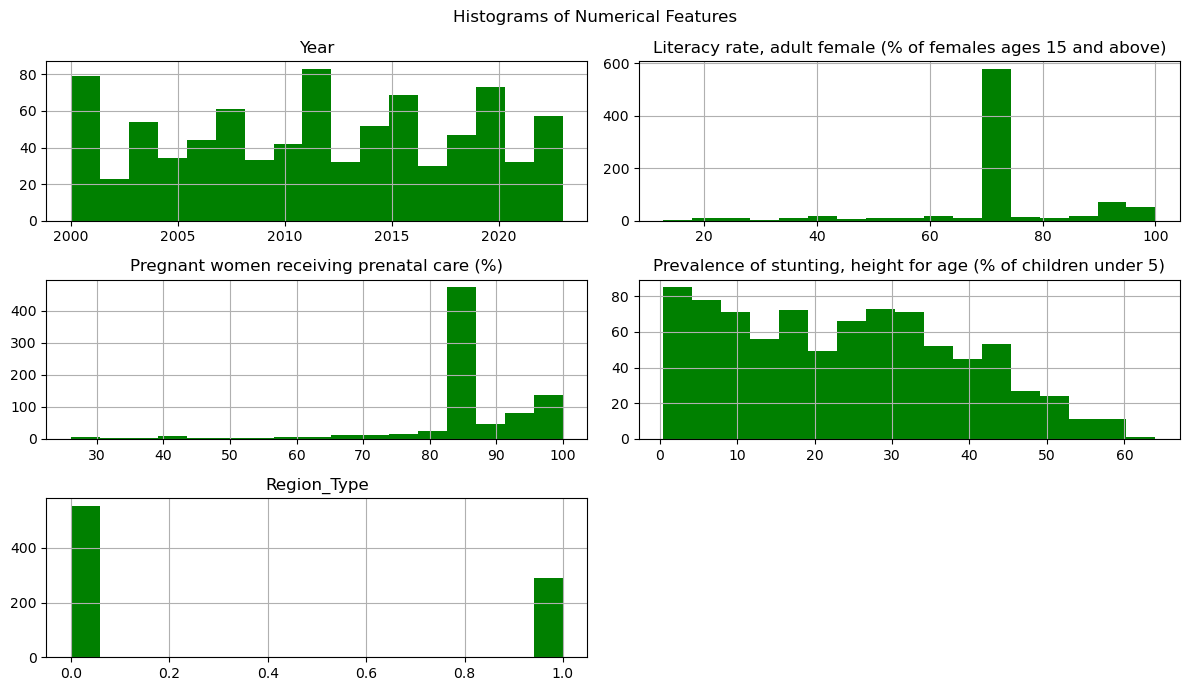

In [20]:
data.hist(bins=17, figsize=(12, 7), color='green')
plt.suptitle('Histograms of Numerical Features')
plt.tight_layout()
plt.show()

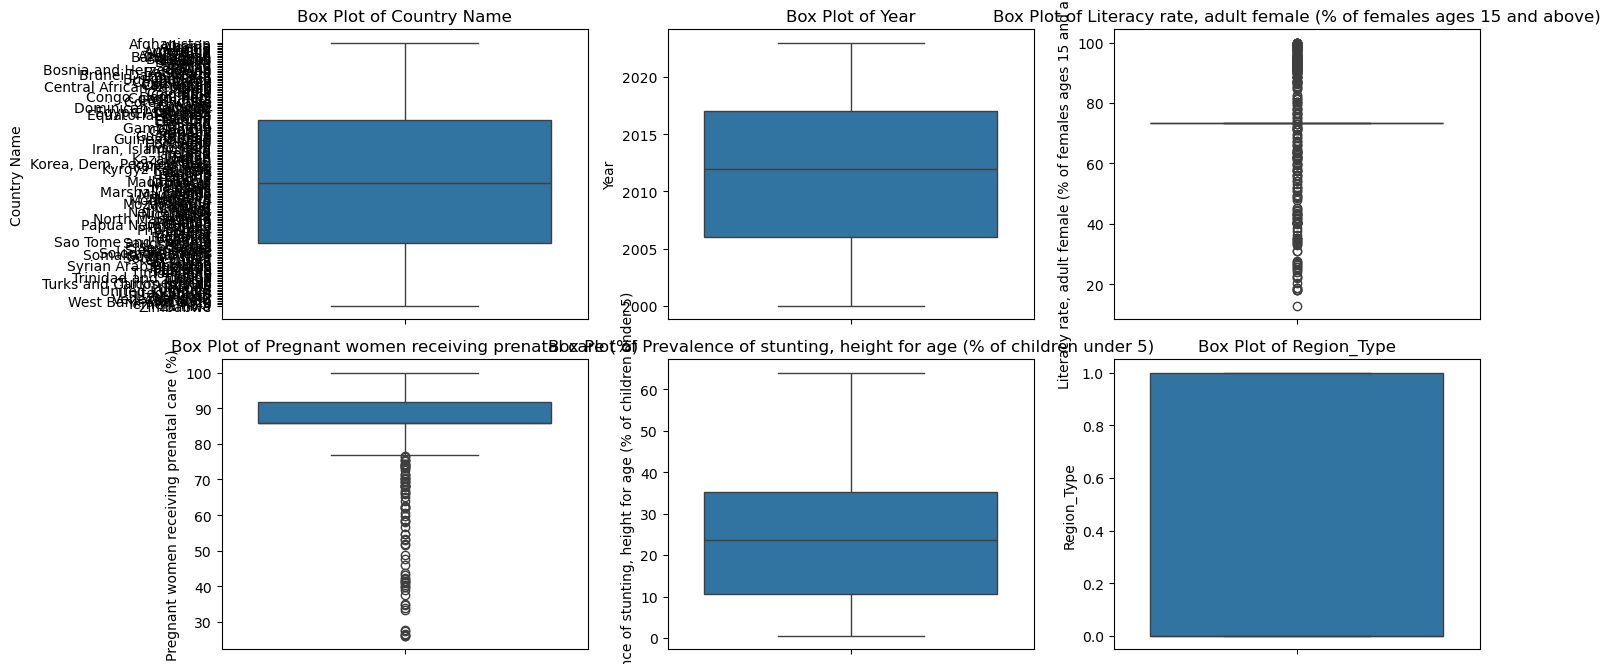

In [21]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(data.columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=data[column])
    plt.title(f'Box Plot of {column}')
plt.tight_layout()
plt.show()

In [22]:
print("Outliers Detection:\n")
outliers_summary = {}
for feature in numerical_features:
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    outliers_summary[feature] = len(outliers)
    print(f"\t{feature}:{len(outliers)} outliers\t")

Outliers Detection:

	Year:0 outliers	
	Literacy rate, adult female (% of females ages 15 and above):280 outliers	
	Pregnant women receiving prenatal care (%):78 outliers	
	Prevalence of stunting, height for age (% of children under 5):0 outliers	
	Region_Type:0 outliers	


In [23]:
from scipy import stats

literacy_col = 'Literacy rate, adult female (% of females ages 15 and above)'
prenatal_col = 'Pregnant women receiving prenatal care (%)'

data_cleaned = data.copy()

# Function to handle outliers using Z-score
def replace_outliers_zscore(df, column, threshold=3):
    """Replace outliers with median using Z-score method"""
    z_scores = np.abs(stats.zscore(df[column]))
    outlier_mask = z_scores > threshold
    num_outliers = outlier_mask.sum()
    
    if num_outliers > 0:
        median_val = df[column].median()
        df.loc[outlier_mask, column] = median_val
        print(f"\n{column}:")
        print(f"  Outliers detected (|z-score| > {threshold}): {num_outliers}")
        print(f"  Replaced with median value: {median_val:.2f}")
    else:
        print(f"\n{column}:")
        print(f"  No outliers detected (|z-score| > {threshold})")
    
    return df

# Apply Z-score replacement for both features
data_cleaned = replace_outliers_zscore(data_cleaned, literacy_col, threshold=3)
data_cleaned = replace_outliers_zscore(data_cleaned, prenatal_col, threshold=3)




Literacy rate, adult female (% of females ages 15 and above):
  Outliers detected (|z-score| > 3): 22
  Replaced with median value: 73.37

Pregnant women receiving prenatal care (%):
  Outliers detected (|z-score| > 3): 26
  Replaced with median value: 85.76


In [24]:
data_cleaned.head()

,Country Name,Year,"Literacy rate, adult female (% of females ages 15 and above)",Pregnant women receiving prenatal care (%),"Prevalence of stunting, height for age (% of children under 5)",Region_Type
0,Afghanistan,2004,73.372808,85.757125,59.3,1
1,Afghanistan,2013,73.372808,85.757125,40.4,0
2,Afghanistan,2018,73.372808,65.200000,38.2,0
3,Afghanistan,2022,73.372808,85.757125,44.6,1
4,Albania,2005,73.372808,97.100000,26.7,0


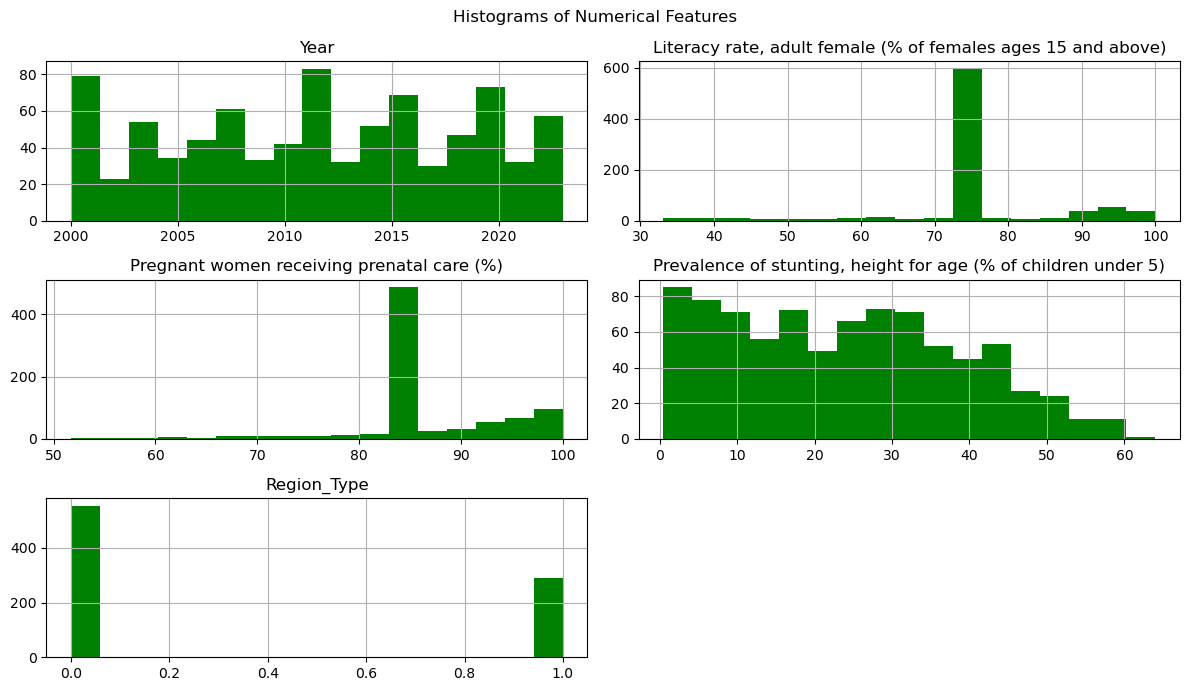

In [25]:
data_cleaned.hist(bins=17, figsize=(12, 7), color='green')
plt.suptitle('Histograms of Numerical Features')
plt.tight_layout()
plt.show()

In [26]:
cr = data_cleaned[numerical_features].corr()
print(cr)

                                                        Year  \
Year                                                1.000000   
Literacy rate, adult female (% of females ages ...  0.062193   
Pregnant women receiving prenatal care (%)          0.089780   
Prevalence of stunting, height for age (% of ch... -0.224149   
Region_Type                                        -0.036420   

                                                    Literacy rate, adult female (% of females ages 15 and above)  \
Year                                                                                         0.062193              
Literacy rate, adult female (% of females ages ...                                           1.000000              
Pregnant women receiving prenatal care (%)                                                   0.197223              
Prevalence of stunting, height for age (% of ch...                                          -0.309611              
Region_Type                        

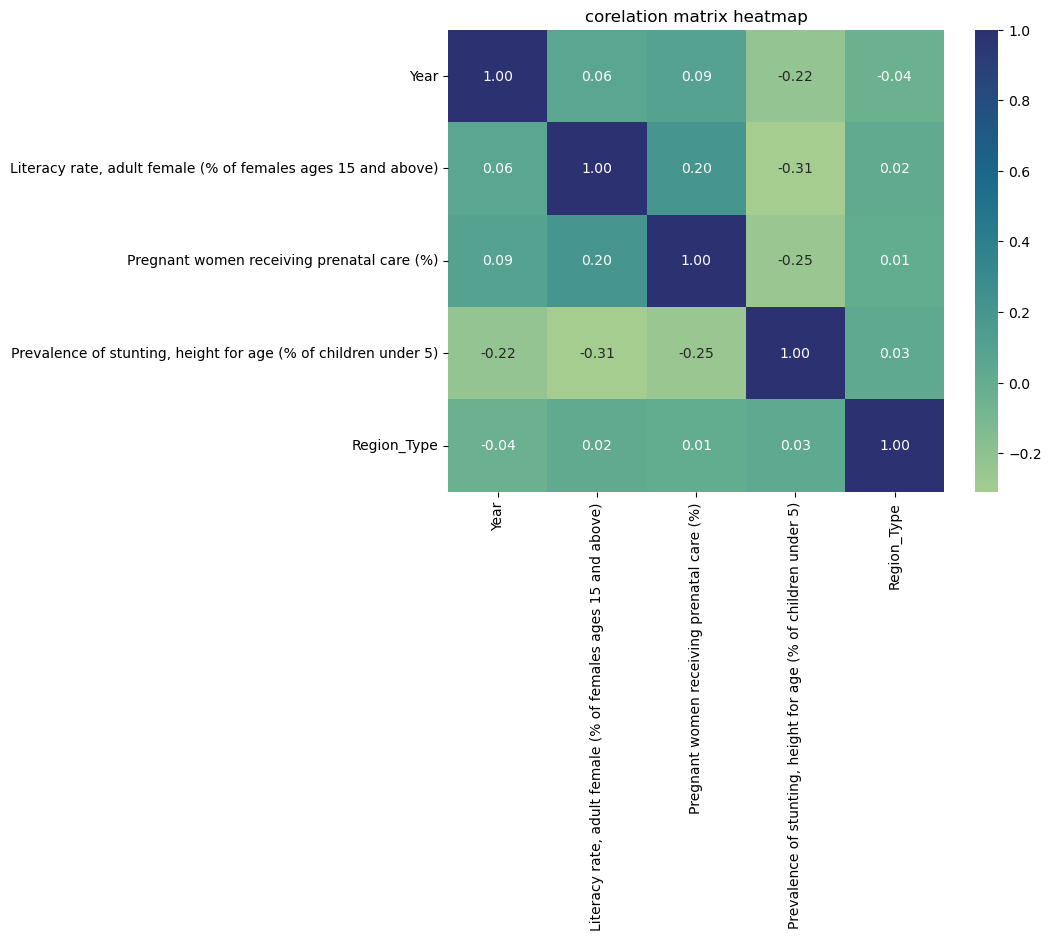

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(cr,annot=True,cmap='crest',fmt='.2f')
plt.title('corelation matrix heatmap')
plt.show()

In [28]:
literacy_col = 'Literacy rate, adult female (% of females ages 15 and above)'
prenatal_col = 'Pregnant women receiving prenatal care (%)'
target_col = 'Prevalence of stunting, height for age (% of children under 5)'

model_data = data_cleaned[[literacy_col, prenatal_col, target_col]].copy()

print(f"Model Data Shape: {model_data.shape}")
#print(f"\nData Summary:\n{model_data.describe()}")

Model Data Shape: (845, 3)


In [29]:
X = model_data[[literacy_col, prenatal_col]]
y = model_data[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")



Training set size: 676
Testing set size: 169


In [30]:
model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [31]:
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\nTraining Set:")
print(f"  MAE: {train_mae:.4f}")
print(f"  R² Score: {train_r2:.4f}")
print(f"\nTesting Set:")
print(f"  MAE: {test_mae:.4f}")
print(f"  R² Score: {test_r2:.4f}")


Training Set:
  MAE: 11.2961
  R² Score: 0.1330

Testing Set:
  MAE: 11.5103
  R² Score: 0.1351


In [32]:
from sklearn.tree import DecisionTreeRegressor

In [33]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)


In [34]:
train_mae_dt = mean_absolute_error(y_train, y_train_pred_dt)
test_mae_dt = mean_absolute_error(y_test, y_test_pred_dt)
train_r2_dt = r2_score(y_train, y_train_pred_dt)
test_r2_dt = r2_score(y_test, y_test_pred_dt)

print(f"\nTraining Set:")
print(f"  MAE: {train_mae_dt:.4f}")
print(f"  R² Score: {train_r2_dt:.4f}")
print(f"\nTesting Set:")
print(f"  MAE: {test_mae_dt:.4f}")
print(f"  R² Score: {test_r2_dt:.4f}")


Training Set:
  MAE: 6.7672
  R² Score: 0.4578

Testing Set:
  MAE: 13.2421
  R² Score: -0.0957


In [35]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

In [37]:
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

print(f"\nRandom Forest Regressor Results:")
print(f"\nTraining Set:")
print(f"  MAE: {train_mae_rf:.4f}")
print(f"  R² Score: {train_r2_rf:.4f}")
print(f"\nTesting Set:")
print(f"  MAE: {test_mae_rf:.4f}")
print(f"  R² Score: {test_r2_rf:.4f}")


Random Forest Regressor Results:

Training Set:
  MAE: 8.3127
  R² Score: 0.4173

Testing Set:
  MAE: 11.9796
  R² Score: 0.0663
